# Book Recommender Project

Books Scrapped from [goodreads](https://www.goodreads.com/book/popular_by_date/2019).

Books API from [openlibrary](https://openlibrary.org/developers/api).

Developed by: Bryan Calderon

#### **PCA and Clustering**

* Importing libraries

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from urllib.parse import urljoin
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#### Feature Engeniering
* Loading final dataset
* Enconding variables and saving for modeling and clustering

In [2]:
df_cluster = pd.read_csv("data/Final_Dataset.csv")

In [ ]:
# Prepare the genres column
df_cluster["genres"] = df_cluster["genres"].fillna("").astype(str)

df_cluster["genres_list"] = (
    df_cluster["genres"]
    .str.lower()
    .str.split(","))

df_cluster["genres_list"] = df_cluster["genres_list"].apply(
    lambda genre_list: [
        genre.strip() 
        for genre in genre_list 
        if genre.strip() != ""])

In [5]:
# List of generic genders
generic_genres = [
    "fiction",
    "general",
    "audiobook",
    "book club"]

In [ ]:
# Creating a column without gender categories that are generic
df_cluster["genres_list_clean"] = df_cluster["genres_list"].apply(
    lambda genre_list: [
        genre 
        for genre in genre_list 
        if genre not in generic_genres])

df_cluster[["title", "genres_list", "genres_list_clean"]].head()

,title,genres_list,genres_list_clean
0,The Hound of the Baskervilles,"[crime novel, english civil war, mires, tors, ...","[crime novel, english civil war, mires, tors, ..."
1,The Classic Tale of the Velveteen Rabbit,"[toys, fiction, children's fiction, toys, fict...","[toys, children's fiction, toys, gift books, a..."
2,No country for old men,"[fiction, drug traffic, sheriffs, treasure-tro...","[drug traffic, sheriffs, treasure-trove, treas..."
3,The Prophet,"[poetry, classics, literature & fiction, relig...","[poetry, classics, literature & fiction, relig..."
4,The Railway Children,"[brothers and sisters, children's stories, cla...","[brothers and sisters, children's stories, cla..."


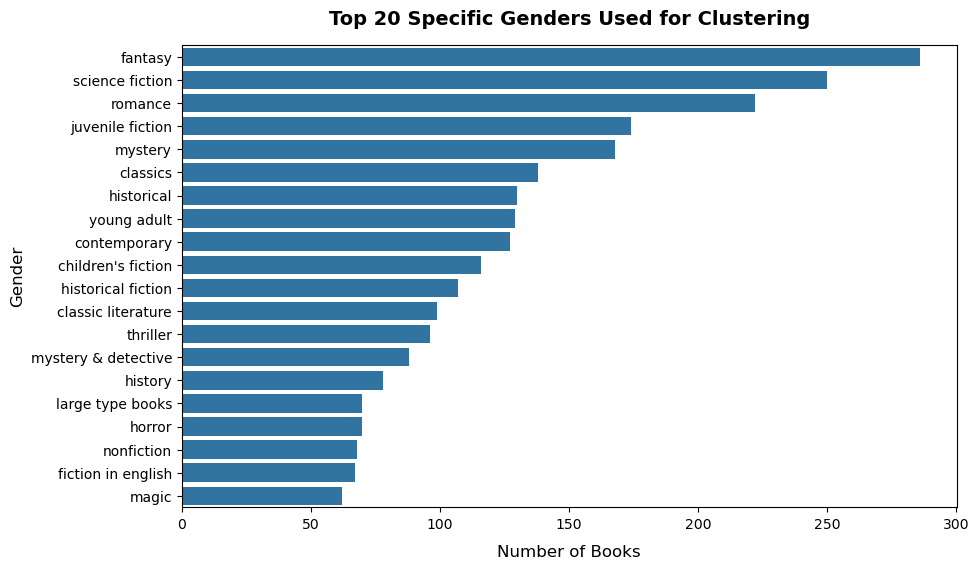

In [7]:
# This is to have a better overview #
top_genres_counts = (
    df_cluster["genres_list_clean"]
    .explode()
    .value_counts()
    .head(20)
    .reset_index())

top_genres_counts.columns = ["genre", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_genres_counts,
    x="count",
    y="genre")

plt.title("Top 20 Specific Genders Used for Clustering", fontsize=14, pad=15, weight="bold")
plt.xlabel("Number of Books", fontsize=12, labelpad=10)
plt.ylabel("Gender", fontsize=12)
plt.show()

In [ ]:
top_20_genres = (
    df_cluster["genres_list_clean"]
    .explode()
    .value_counts()
    .head(20)
    .index
    .tolist())

In [10]:
for genre in top_20_genres:
    clean_column_name = (
        "genre_" 
        + genre
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("&", "and")
        .replace("'", "")
        .replace(".", "")
        .replace(",", ""))
    
    df_cluster[clean_column_name] = df_cluster["genres_list_clean"].apply(
        lambda genre_list: 1 if genre in genre_list else 0)

In [11]:
genre_features = [col for col in df_cluster.columns if col.startswith("genre_")]
df_cluster[["title"] + genre_features].head()

,title,genre_fantasy,genre_science_fiction,genre_romance,genre_juvenile_fiction,genre_mystery,genre_classics,genre_historical,genre_young_adult,genre_contemporary,...,genre_historical_fiction,genre_classic_literature,genre_thriller,genre_mystery_and_detective,genre_history,genre_large_type_books,genre_horror,genre_nonfiction,genre_fiction_in_english,genre_magic
0,The Hound of the Baskervilles,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,The Classic Tale of the Velveteen Rabbit,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,No country for old men,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,The Prophet,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,The Railway Children,0,0,0,1,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0


* **Building the final feature matrix**

In [12]:
numeric_features = [
    "average_rating",
    "ratings_count",
    "reviews_count",
    "pages",
    "source_year"]

features = numeric_features + genre_features
X = df_cluster[features]
X.head()

,average_rating,ratings_count,reviews_count,pages,source_year,genre_fantasy,genre_science_fiction,genre_romance,genre_juvenile_fiction,genre_mystery,...,genre_historical_fiction,genre_classic_literature,genre_thriller,genre_mystery_and_detective,genre_history,genre_large_type_books,genre_horror,genre_nonfiction,genre_fiction_in_english,genre_magic
0,4.016667,60,0,375,1900,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,4.125000,40,0,375,1900,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,4.111111,36,0,375,1900,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4.321429,56,0,375,1900,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3.965517,29,0,375,1900,0,0,0,1,0,...,0,1,0,0,1,0,0,0,0,0


In [15]:
# Scaling the features / Normalizing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.01692801, -0.45143013, -0.46419021, ..., -0.24201281,
        -0.24012332, -0.22255407],
       [ 0.27270154, -0.45145238, -0.46419021, ..., -0.24201281,
        -0.24012332, -0.22255407],
       [ 0.23556914, -0.45145683, -0.46419021, ..., -0.24201281,
        -0.24012332, -0.22255407],
       ...,
       [-0.35557373,  0.75540562,  1.58345514, ..., -0.24201281,
        -0.24012332, -0.22255407],
       [ 0.41974469,  1.08243035,  2.98427962, ..., -0.24201281,
        -0.24012332, -0.22255407],
       [ 1.51588453,  1.46027141,  3.10784981, ..., -0.24201281,
        -0.24012332, -0.22255407]], shape=(1229, 25))

* Elbow method

In [16]:
inertias = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

inertias

[27248.399625537917,
 25546.745321233102,
 23814.559222223863,
 22215.154402115306,
 20773.679767194008,
 19923.941618829245,
 18591.908339044963,
 17452.55863438724,
 16926.777452844173]

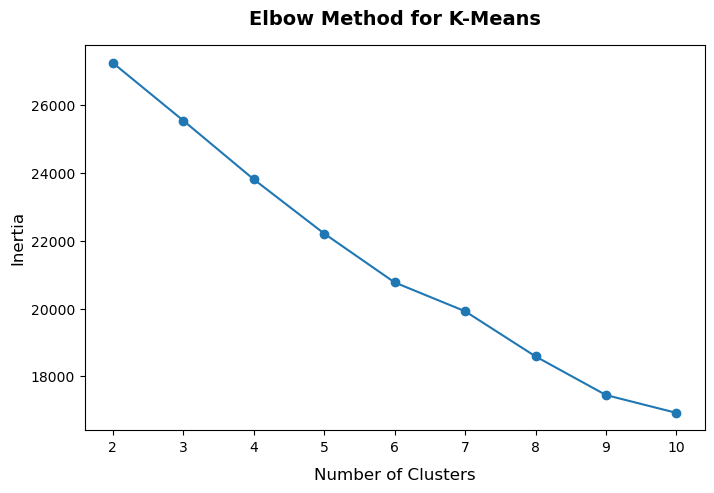

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")

plt.title("Elbow Method for K-Means", fontsize=14, pad=15, weight="bold")
plt.xlabel("Number of Clusters", fontsize=12, labelpad=10)
plt.ylabel("Inertia", fontsize=12)
plt.xticks(K_range)
plt.show()

From this elbow plot, there is no very sharp elbow. The inertia decreases smoothly from k=2 to k=10.

I choose to continue with k=6 for optimal model selection.

* Silhouette score

In [18]:
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_scores

[0.16479860232311858,
 0.10074917988470652,
 0.14708451624915622,
 0.14401422392649518,
 0.17100970201243387,
 0.18157526148841546,
 0.20958862581594426,
 0.2071749137950776,
 0.2250233985352423]

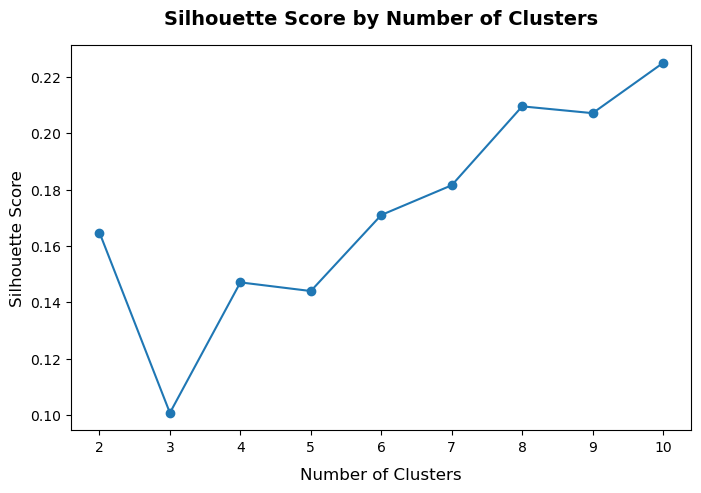

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")

plt.title("Silhouette Score by Number of Clusters", fontsize=14, pad=15, weight="bold")
plt.xlabel("Number of Clusters", fontsize=12, labelpad=10)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(K_range)
plt.show()

The final selection is stil k=6

In [20]:
kmeans_final = KMeans(
    n_clusters=6,         # The best is 6
    random_state=42,
    n_init=10)

df_cluster["cluster"] = kmeans_final.fit_predict(X_scaled)

In [21]:
df_cluster["cluster"].value_counts().sort_index()

cluster
0    119
1    545
2     94
3    200
4    203
5     68
Name: count, dtype: int64

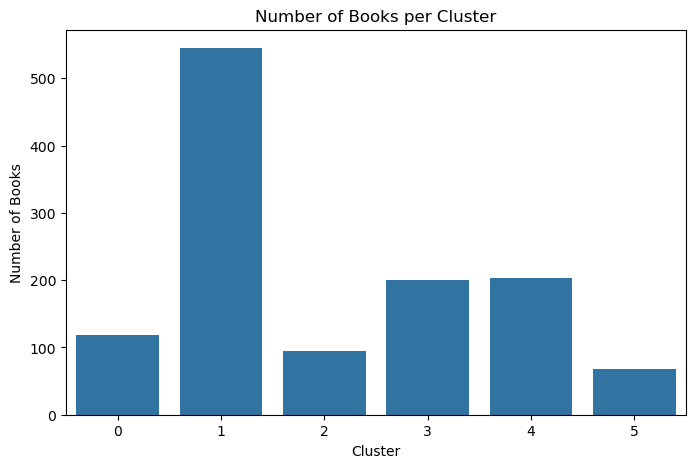

In [ ]:
cluster_counts = (
    df_cluster["cluster"]
    .value_counts()
    .sort_index()
    .reset_index())

cluster_counts.columns = ["cluster", "book_count"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=cluster_counts,
    x="cluster",
    y="book_count")

plt.title("Number of Books per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Books")
plt.show()

In [22]:
cluster_summary = (
    df_cluster
    .groupby("cluster")
    .agg(
        book_count=("title", "count"),
        avg_rating=("average_rating", "mean"),
        avg_ratings_count=("ratings_count", "mean"),
        avg_reviews_count=("reviews_count", "mean"),
        avg_pages=("pages", "mean"),
        avg_year=("source_year", "mean"))
    .reset_index())

cluster_summary.round(2)

,cluster,book_count,avg_rating,avg_ratings_count,avg_reviews_count,avg_pages,avg_year
0,0,119,4.08,407325.31,22486.13,434.63,1966.02
1,1,545,3.97,45284.04,2381.59,373.16,1945.05
2,2,94,4.05,865934.23,50450.03,410.74,1994.06
3,3,200,4.00,30.25,0.00,375.00,1936.13
4,4,203,4.09,1512879.80,88165.97,415.00,2006.29
5,5,68,4.16,543029.84,25347.87,366.79,1994.79


The K-Means model grouped the books into six clusters based on numerical characteristics and encoded genre information. Cluster 1 is the largest group, suggesting that many books share a common general profile. Smaller clusters represent more specific book profiles. Cluster 5 has the highest average rating, while Cluster 1 has the lowest average rating among the clusters.

* Gender cluster / Summary

In [23]:
genre_cluster_summary = (
    df_cluster
    .groupby("cluster")[genre_features]
    .mean()
    .reset_index())

genre_cluster_summary

,cluster,genre_fantasy,genre_science_fiction,genre_romance,genre_juvenile_fiction,genre_mystery,genre_classics,genre_historical,genre_young_adult,genre_contemporary,...,genre_historical_fiction,genre_classic_literature,genre_thriller,genre_mystery_and_detective,genre_history,genre_large_type_books,genre_horror,genre_nonfiction,genre_fiction_in_english,genre_magic
0,0,0.134454,0.008403,0.420168,0.008403,0.075630,0.327731,0.857143,0.042017,0.058824,...,0.605042,0.075630,0.008403,0.008403,0.184874,0.058824,0.016807,0.0,0.016807,0.008403
1,1,0.126606,0.233028,0.036697,0.003670,0.113761,0.080734,0.001835,0.003670,0.023853,...,0.027523,0.117431,0.005505,0.121101,0.029358,0.106422,0.045872,0.0,0.115596,0.025688
2,2,0.287234,0.138298,0.031915,0.000000,0.787234,0.159574,0.000000,0.074468,0.138298,...,0.063830,0.021277,0.968085,0.000000,0.010638,0.000000,0.404255,0.0,0.000000,0.000000
3,3,0.215000,0.050000,0.005000,0.855000,0.035000,0.010000,0.015000,0.000000,0.000000,...,0.020000,0.120000,0.000000,0.005000,0.065000,0.025000,0.000000,0.0,0.010000,0.100000
4,4,0.566502,0.123153,0.640394,0.000000,0.068966,0.147783,0.000000,0.566502,0.458128,...,0.049261,0.000000,0.004926,0.000000,0.000000,0.000000,0.009852,0.0,0.000000,0.113300
5,5,0.000000,0.000000,0.029412,0.000000,0.029412,0.117647,0.117647,0.000000,0.014706,...,0.000000,0.000000,0.000000,0.000000,0.338235,0.000000,0.000000,1.0,0.000000,0.000000


In [24]:
for cluster in sorted(df_cluster["cluster"].unique()):
    print(f"\nCluster {cluster} - Top Genres")
    
    cluster_genres = (genre_cluster_summary[genre_cluster_summary["cluster"] == cluster]
        .drop(columns="cluster")
        .T
        .reset_index())
    
    cluster_genres.columns = ["genre", "share"]
    cluster_genres = cluster_genres.sort_values("share", ascending=False).head(5)
    
    display(cluster_genres)


Cluster 0 - Top Genres


,genre,share
6,genre_historical,0.857143
10,genre_historical_fiction,0.605042
2,genre_romance,0.420168
5,genre_classics,0.327731
14,genre_history,0.184874



Cluster 1 - Top Genres


,genre,share
1,genre_science_fiction,0.233028
0,genre_fantasy,0.126606
13,genre_mystery_and_detective,0.121101
11,genre_classic_literature,0.117431
18,genre_fiction_in_english,0.115596



Cluster 2 - Top Genres


...

,genre,share
3,genre_juvenile_fiction,0.855
9,genre_childrens_fiction,0.580
0,genre_fantasy,0.215
11,genre_classic_literature,0.120
19,genre_magic,0.100



Cluster 4 - Top Genres


,genre,share
2,genre_romance,0.640394
0,genre_fantasy,0.566502
7,genre_young_adult,0.566502
8,genre_contemporary,0.458128
5,genre_classics,0.147783



Cluster 5 - Top Genres


,genre,share
17,genre_nonfiction,1.000000
14,genre_history,0.338235
6,genre_historical,0.117647
5,genre_classics,0.117647
4,genre_mystery,0.029412


In [25]:
# With such information we can define better the clustering names #
cluster_labels = {
    0: "Historical & classic fiction",
    1: "General genre fiction",
    2: "Thriller, mystery & horror",
    3: "Children’s & juvenile fantasy",
    4: "Romance, fantasy & young adult",
    5: "Nonfiction & history"}

df_cluster["cluster_label"] = df_cluster["cluster"].map(cluster_labels)

The clusters represent different book profiles, including historical and classic fiction, general genre fiction, thriller/mystery/horror, children’s and juvenile fantasy, romance/fantasy/young adult, and nonfiction/history.

In [26]:
cluster_summary_labeled = (
    df_cluster
    .groupby(["cluster", "cluster_label"])
    .agg(
        book_count=("title", "count"),
        avg_rating=("average_rating", "mean"),
        avg_ratings_count=("ratings_count", "mean"),
        avg_reviews_count=("reviews_count", "mean"),
        avg_pages=("pages", "mean"),
        avg_year=("source_year", "mean"))
    .reset_index())

cluster_summary_labeled.round(2)

,cluster,cluster_label,book_count,avg_rating,avg_ratings_count,avg_reviews_count,avg_pages,avg_year
0,0,Historical & classic fiction,119,4.08,407325.31,22486.13,434.63,1966.02
1,1,General genre fiction,545,3.97,45284.04,2381.59,373.16,1945.05
2,2,"Thriller, mystery & horror",94,4.05,865934.23,50450.03,410.74,1994.06
3,3,Children’s & juvenile fantasy,200,4.00,30.25,0.00,375.00,1936.13
4,4,"Romance, fantasy & young adult",203,4.09,1512879.80,88165.97,415.00,2006.29
5,5,Nonfiction & history,68,4.16,543029.84,25347.87,366.79,1994.79


In [ ]:
for cluster in sorted(df_cluster["cluster"].unique()):
    print(f"\nCluster {cluster}")
    
    display(
        df_cluster[df_cluster["cluster"] == cluster][
            [   "title",
                "author",
                "source_year",
                "average_rating",
                "ratings_count",
                "genres",
                "source"
            ]
        ].head(10)
    )


Cluster 0


,title,author,source_year,average_rating,ratings_count,genres,source
11,Tahreer ka sehar,H. Rider Haggard,1901,4.000000,1,"Fiction, History, Fiction, historical, general...",Open Library API
26,Noli Me Tangere,José Rizal,1902,4.400000,10,"Economics, Classic Literature, Fiction, Fictio...",Open Library API
30,The Ambassadors,Henry James,1903,4.250000,8,"Man-woman relationships, Fiction, Romance, Ame...",Open Library API
63,Sir Nigel,Arthur Conan Doyle,1906,4.000000,4,"Classic Literature, Ficion, Fiction, Great Bri...",Open Library API
75,The Elusive Pimpernel (Scarlet Pimpernel),Emma Orczy,1908,3.571429,7,"Fiction, action & adventure, Fiction, historic...",Open Library API
118,So speaks the heart,Johanna Lindsey,1912,4.500000,6,"Fiction, France, Social life and customs, Hist...",Open Library API
126,Обломов,Ива́н Алекса́ндрович Гончаро́в,1913,3.750000,8,"Fiction, Readers, Russia in fiction, Russian l...",Open Library API
128,El Dorado,Emma Orczy,1913,3.476191,21,"Classic Literature, Fiction, Historical Fictio...",Open Library API
155,The Mysterious Stranger,Mark Twain,1916,3.800000,5,"American Humorous stories, Social life and cus...",Open Library API
160,Summer,Edith Wharton,1917,3.833333,6,"Fiction, Romance, Historical, Victorian, Young...",Open Library API



Cluster 1


,title,author,source_year,average_rating,ratings_count,genres,source
0,The Hound of the Baskervilles,Arthur Conan Doyle,1900,4.016667,60,"crime novel, English Civil War, mires, tors, t...",Open Library API
2,No country for old men,Cormac McCarthy,1900,4.111111,36,"Fiction, Drug traffic, Sheriffs, Treasure-trov...",Open Library API
3,The Prophet,Kahlil Gibran,1900,4.321429,56,"Poetry, Classics, Literature & Fiction, Religion",Open Library API
5,The Scarlet Pimpernel,Emma Orczy,1900,4.250000,28,"Classic Literature, Adventure and adventurers,...",Open Library API
6,The Lost World,Arthur Conan Doyle,1900,4.045454,44,"Adventure stories, Atlantis, Dinosaurs, Discov...",Open Library API
7,The Clan of the Cave Bear,Jean M. Auel,1900,4.054794,73,"Neanderthals, shamanism, sign language, taboos...",Open Library API
8,The food of the gods and how it came to earth,H. G. Wells,1900,3.777778,18,"Fiction, Giants, Growth factors, Food supply, ...",Open Library API
9,Semilla del Diablo,Ira Levin,1900,4.000000,22,"Fiction, horror, Fiction, Satanism, Occult fic...",Open Library API
10,The four feathers,A. E. W. Mason,1901,3.000000,2,"Cowardice, Male friendship, Open Library Staff...",Open Library API
12,The Fixer,Bernard Malamud,1901,5.000000,1,"Fiction, Trials (Murder), Jews, Antisemitism, ...",Open Library API



Cluster 2


...

,title,author,source_year,average_rating,ratings_count,genres,source
1,The Classic Tale of the Velveteen Rabbit,Margery Williams Bianco,1900,4.125000,40,"Toys, Fiction, Children's fiction, Toys, ficti...",Open Library API
4,The Railway Children,Edith Nesbit,1900,3.965517,29,"Brothers and sisters, Children's stories, Clas...",Open Library API
14,The Wouldbegoods,Edith Nesbit,1901,3.000000,1,"Classic Literature, Fiction, Juvenile Literatu...",Open Library API
17,The Violet Fairy Book (Large Print),Andrew Lang,1901,4.000000,8,"Fairy tales, Children's fiction, Fiction, fant...",Open Library API
19,Number the Stars,Lois Lowry,1901,4.173077,104,"Fiction, Friendship, Rescue, World War, 1939-1...",Open Library API
25,The Complete Life and Adventures of Santa Claus,L. Frank Baum,1902,4.250000,4,"Fantasy, Fiction, Juvenile Fiction, Science Fi...",Open Library API
29,The Tale of Squirrel Nutkin,"Beatrix Potter, Wendy Rasmussen, H y Xiao Phd",1903,3.777778,9,"Squirrels, Fiction, Children's fiction, Squirr...",Open Library API
31,The Enchanted Island of Yew,L. Frank Baum,1903,4.000000,1,"Fantasy, Fiction, Juvenile Fiction, Classic Li...",Open Library API
32,The Tailor of Gloucester,"Beatrix Potter, H y Xiao Phd",1903,4.000000,5,"Cats, Children's stories, English, Christmas, ...",Open Library API
34,The Phoenix and the Carpet,Edith Nesbit,1903,3.100000,10,"English Fantasy fiction, Magic, Brothers and s...",Open Library API



Cluster 4


,title,author,source_year,average_rating,ratings_count,genres,source
555,Stars Through the Mist,Betty Neels,1957,3.866667,15,"Fiction, Romance, Contemporary, Nurses, fictio...",Open Library API
557,The Moon for Lavinia,Betty Neels,1957,4.000000,10,"Fiction, Romance, Contemporary, Nurses, fictio...",Open Library API
691,Sweet Revenge,Anne Mather,1970,3.705882,17,"Fiction, Romance, Contemporary",Open Library API
728,Leopard in the Snow,Anne Mather,1974,3.500000,20,"Fiction, Romance, Contemporary, Prisoner, fict...",Open Library API
738,Forever...,Judy Blume,1975,3.620000,68419,"Young Adult, Romance, Fiction, Banned Books, C...",Goodreads Popular by Year
739,Danny the Champion of the World,Roald Dahl,1975,4.100000,73892,"Fiction, Childrens, Classics, Middle Grade, Fa...",Goodreads Popular by Year
740,Temporary Wife,Roberta Leigh,1975,3.913044,23,"Fiction, Romance, Contemporary",Open Library API
743,Take What You Want,Anne Mather,1975,3.705882,17,"Fiction, Romance, Contemporary",Open Library API
747,Tuck Everlasting,Natalie Babbitt,1975,3.910000,299733,"Fantasy, Classics, Young Adult, Fiction, Child...",Goodreads Popular by Year
771,Bridge to Terabithia,Katherine Paterson,1977,4.060000,598142,"Fiction, Young Adult, Classics, Fantasy, Child...",Goodreads Popular by Year



Cluster 5


,title,author,source_year,average_rating,ratings_count,genres,source
737,The Miracle of Mindfulness: An Introduction to...,Thich Nhat Hanh,1975,4.18,40450,"Nonfiction, Spirituality, Buddhism, Philosophy...",Goodreads Popular by Year
749,Discipline and Punish: The Birth of the Prison,Michel Foucault,1975,4.23,37806,"Philosophy, Nonfiction, History, Sociology, Th...",Goodreads Popular by Year
758,All Things Bright and Beautiful,James Herriot,1976,4.36,84082,"Nonfiction, Animals, Memoir, Biography, Classi...",Goodreads Popular by Year
761,The Selfish Gene,Richard Dawkins,1976,4.16,195707,"Science, Nonfiction, Biology, Evolution, Philo...",Goodreads Popular by Year
763,On Writing Well: The Classic Guide to Writing ...,William Zinsser,1976,4.24,31345,"Writing, Nonfiction, Reference, Business, Self...",Goodreads Popular by Year
764,A Course in Miracles: Combined Volume,Helen Schucman,1976,4.20,34375,"Spirituality, Nonfiction, Self Help, Philosoph...",Goodreads Popular by Year
778,The Road Less Traveled: A New Psychology of Lo...,M. Scott Peck,1978,4.08,103528,"Psychology, Nonfiction, Self Help, Spiritualit...",Goodreads Popular by Year
780,Orientalism,Edward W. Said,1978,4.14,30712,"Nonfiction, History, Philosophy, Politics, The...",Goodreads Popular by Year
786,The New Drawing on the Right Side of the Brain,Betty Edwards,1979,3.87,384324,"Art, Nonfiction, Drawing, Reference, Psycholog...",Goodreads Popular by Year
788,The Rise of Theodore Roosevelt,Edmund Morris,1979,4.22,62074,"Biography, History, Nonfiction, Presidents, Am...",Goodreads Popular by Year


#### PCA analysis

In [27]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

df_cluster["pca_1"] = pca_result[:, 0]
df_cluster["pca_2"] = pca_result[:, 1]

In [28]:
explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")

PC1 explained variance: 15.09%
PC2 explained variance: 7.91%
Total explained variance: 22.99%


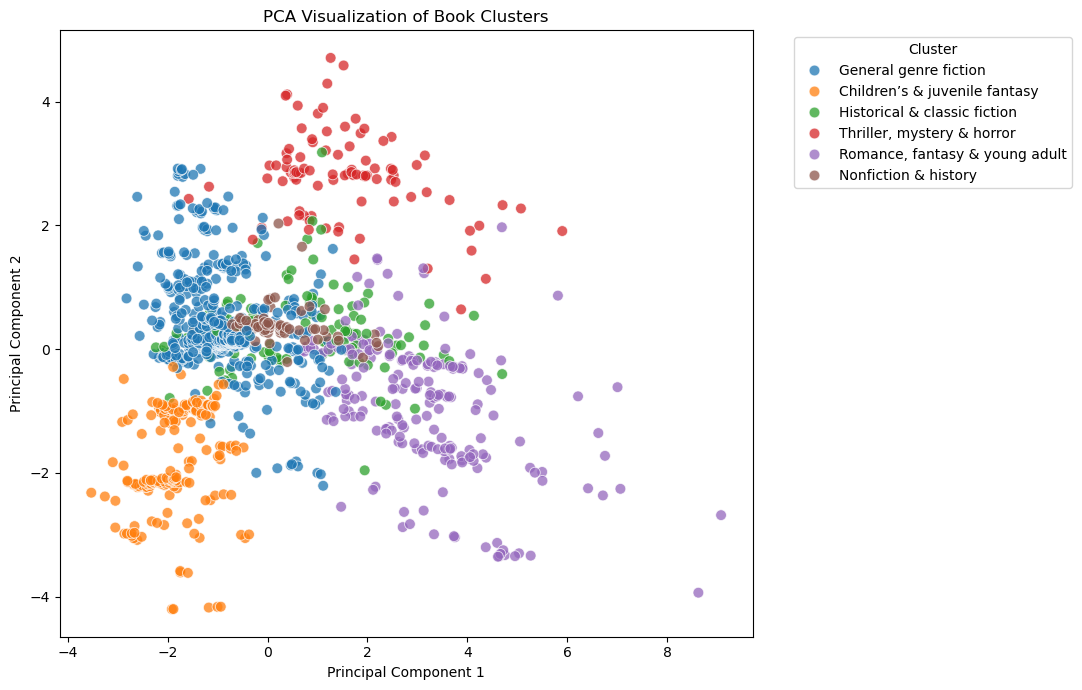

In [29]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_cluster,
    x="pca_1",
    y="pca_2",
    hue="cluster_label",
    alpha=0.75,
    s=60)

plt.title("PCA Visualization of Book Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Some genre groups clearly occupy different regions of the PCA space.

The PCA plot provides a useful visual approximation of the clusters, but it does not represent all the information used by K-Means.

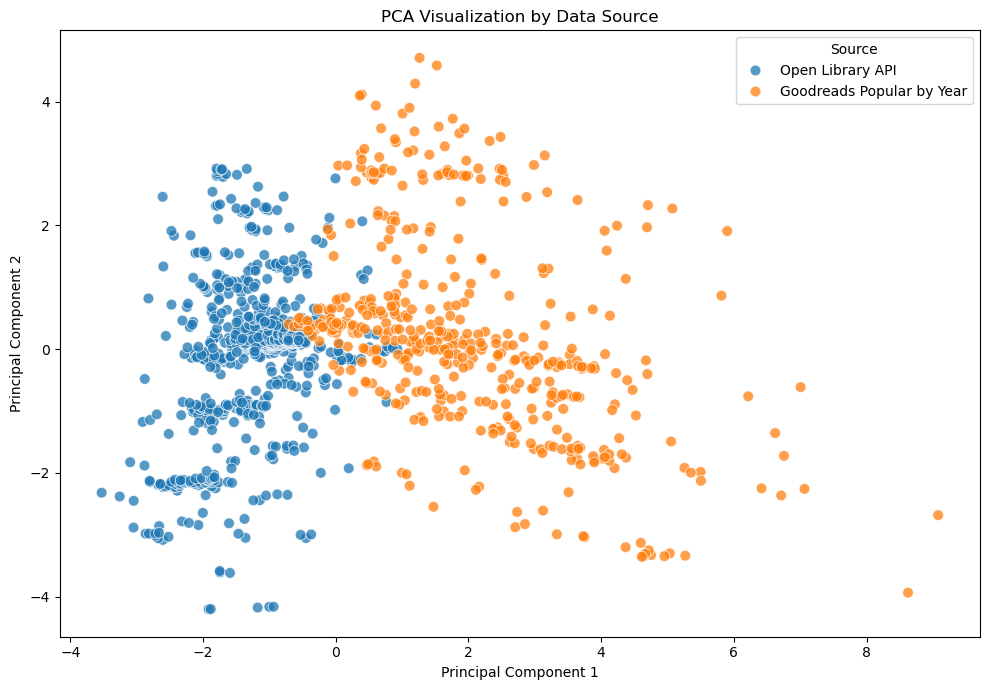

In [30]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_cluster,
    x="pca_1",
    y="pca_2",
    hue="source",
    alpha=0.75,
    s=60)

plt.title("PCA Visualization by Data Source")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Source")
plt.tight_layout()
plt.show()

PC1 partly separates books by data source, which reflects differences in publication years, ratings/reviews availability, and metadata structure.

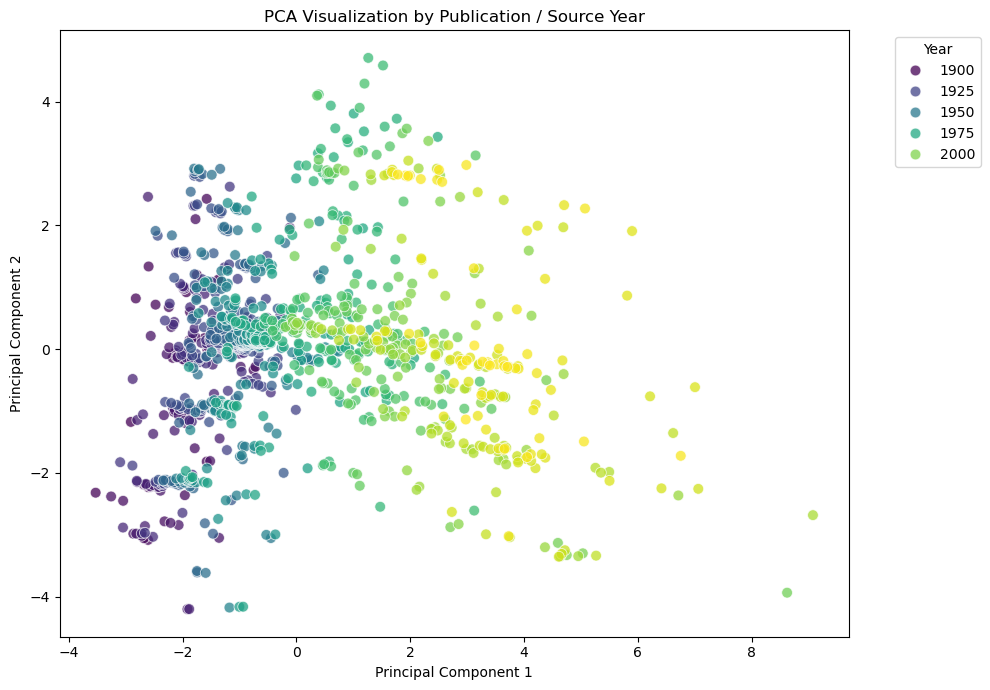

In [31]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_cluster,
    x="pca_1",
    y="pca_2",
    hue="source_year",
    palette="viridis",
    alpha=0.75,
    s=60)

plt.title("PCA Visualization by Publication / Source Year")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

PC1 captures a historical/popularity dimension, separating older books from newer and more digitally reviewed books.

In [32]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features)

pca_loadings.head()

,PC1,PC2
average_rating,0.125314,-0.038197
ratings_count,0.409020,-0.088788
reviews_count,0.420630,-0.057260
pages,0.100834,-0.070048
source_year,0.435070,0.061996


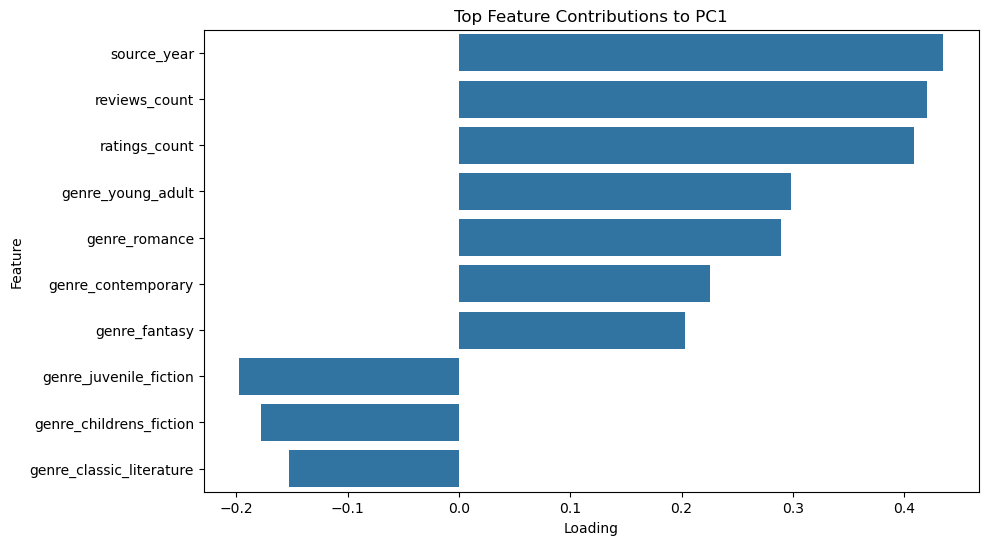

In [33]:
pc1_top = (
    pca_loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=pca_loadings.loc[pc1_top, "PC1"],
    y=pc1_top)

plt.title("Top Feature Contributions to PC1")
plt.xlabel("Loading")
plt.ylabel("Feature")
plt.show()

PC1 separates newer, highly engaged contemporary/romance/fantasy books from older or more classic/children’s literature.

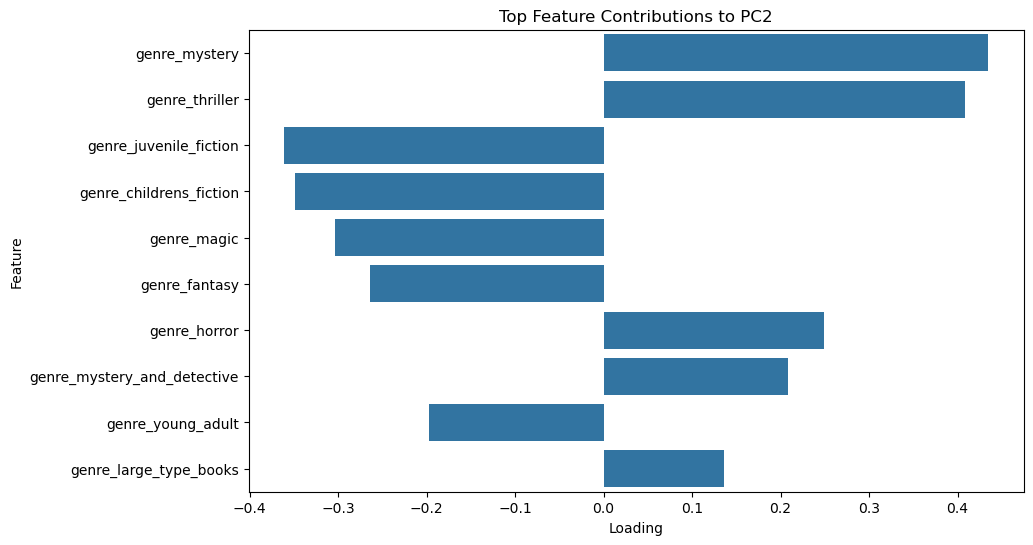

In [34]:
pc2_top = (
    pca_loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=pca_loadings.loc[pc2_top, "PC2"],
    y=pc2_top)

plt.title("Top Feature Contributions to PC2")
plt.xlabel("Loading")
plt.ylabel("Feature")
plt.show()

PC2 mainly separates mystery, thriller, and horror books from children’s, juvenile, magical, and fantasy-oriented books.

* Saving clustered data with PCA

In [38]:
df_cluster.to_csv("data/books_with_clusters_pca.csv", index=False)